# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [67]:
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder

import os
from zipfile import ZipFile
from typing import Tuple

import matplotlib.pyplot as plt
from collections import Counter

## Descarga del dataset

In [2]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0   105M      0  0:00:01  0:00:01 --:--:--  224M


In [10]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [8]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## EDA


Primero definimos una transformación básica en donde se aplica la transformación [ToTensor](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html).

Esta permite convertir una imagen en un *tensor*, lo cual es necesario para trabajar con algunos modelos de PyTorch. También permite escalar los valores de píxeles originales (rango $[0; 255]$) al rango $[0; 1]$.

Por el momento solo se aplica esta transformación, ya que deseamos hacer un análisis inicial del dataset, pero en pasos posteriores se agregarán otras transformaciones según sea conveniente.



In [12]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])

Se crean los datasets de `train`, `test` y `validation` utilizando la clase [ImageFolder](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html).

En cada uno se aplica la transformación base definida en `basic_transform`.

In [14]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=basic_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=basic_transform)

En cada dataset se tienen las siguientes cantidades de imágenes:

- `Train`: $613$
- `Test`: $315$
- `Validation`: $72$

In [15]:
print(f"Cantidad de imágenes en Train: {len(train_data)}")
print(f"Cantidad de imágenes en Test: {len(test_data)}")
print(f"Cantidad de imágenes en Validation: {len(validation_data)}")

Cantidad de imágenes en Train: 613
Cantidad de imágenes en Test: 315
Cantidad de imágenes en Validation: 72


A continuación se definen las siguientes funciones:

- `get_class_counts`: dado un dataset formado mediante un `ImageFolder`, devuelve una lista con el nombre de las clases y otra con la cantidad de ocurrencias de cada una.
- `plot_image_class_distribution`: realiza un gráfico de cantidad de ocurrencias de cada clase en un dataset formado por `ImageFolder`.

In [69]:
def get_class_counts(dataset: ImageFolder) -> Tuple[list, list]:
  """
  Dado un dataset de tipo ImageFolder, devuelve las clases y
  su cantidad de ocurrencias.

  Args:
    dataset (ImageFolder): Dataset sobre el cual se obtendrán las
      clases y sus cantidades de ocurrencias.
  Returns:
    Tuple[list, list]: Devuelve dos listas:
      class_names: nombre de clases del dataset.
      counts: cantidad de ocurrencia de cada clase en el dataset.
  """
  class_labels = dataset.targets
  class_counts = Counter(class_labels)
  class_names = train_data.classes
  counts = [class_counts[i] for i in range(len(class_names))]

  return class_names, counts

In [76]:
def plot_image_class_distribution(dataset: ImageFolder,
                                  datasetName: str = "train",
                                  figsize: tuple = (10, 6)):
  """
  Grafica la distribución de clases de un dataset de imágenes.

  Args:
    dataset (ImageFolder): dataset cuyas clases se graficarán.
    datasetName (str): nombre del dataset, que se utilizará para el título
      del gráfico.
    figsize (tuple): tamaño del gráfico. Por defecto es (10, 6).
  """
  class_names, counts = get_class_counts(dataset=dataset)

  plt.figure(figsize=figsize)
  plt.barh(class_names, counts)
  plt.xlabel("Cantidad de imágenes")
  plt.ylabel("Clases")
  plt.title(f"Distribución de imágenes por clases en dataset {datasetName}")
  plt.tight_layout()
  plt.show()

### Distribuciones de clases en cada dataset

El dataset de train tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $195$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $115$ |
| `normal` | $148$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $155$ |

Es decir, el dataset de `train` presenta un ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene, y `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` las que menos tiene.

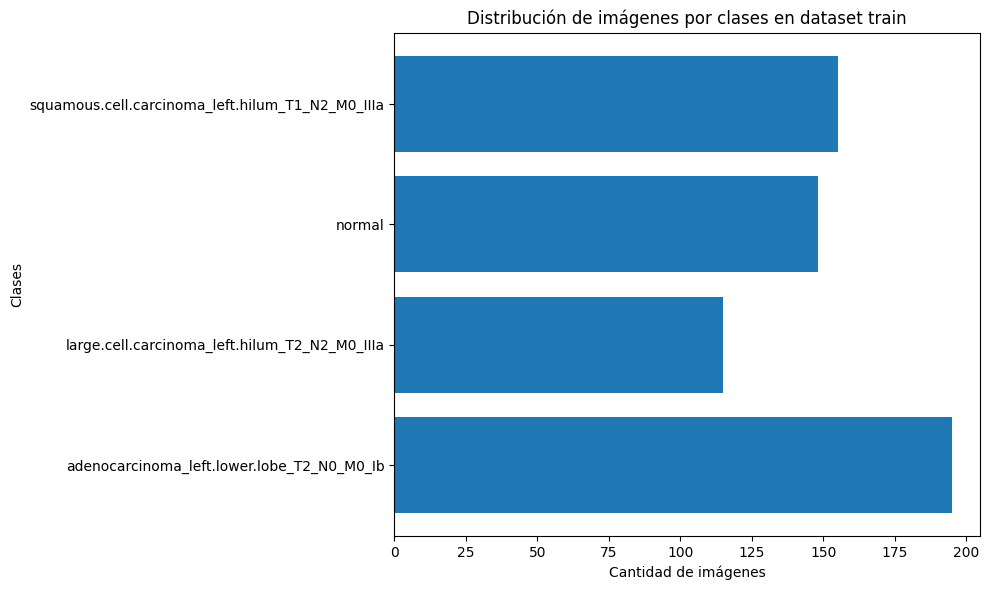

In [77]:
plot_image_class_distribution(dataset=train_data, datasetName="train")

El dataset de `test` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $120$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $51$ |
| `normal` | $54$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $90$ |

Es decir, el dataset de `test` presenta ligero desbalance de clases, siendo `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` la que mayor ocurrencias tiene.

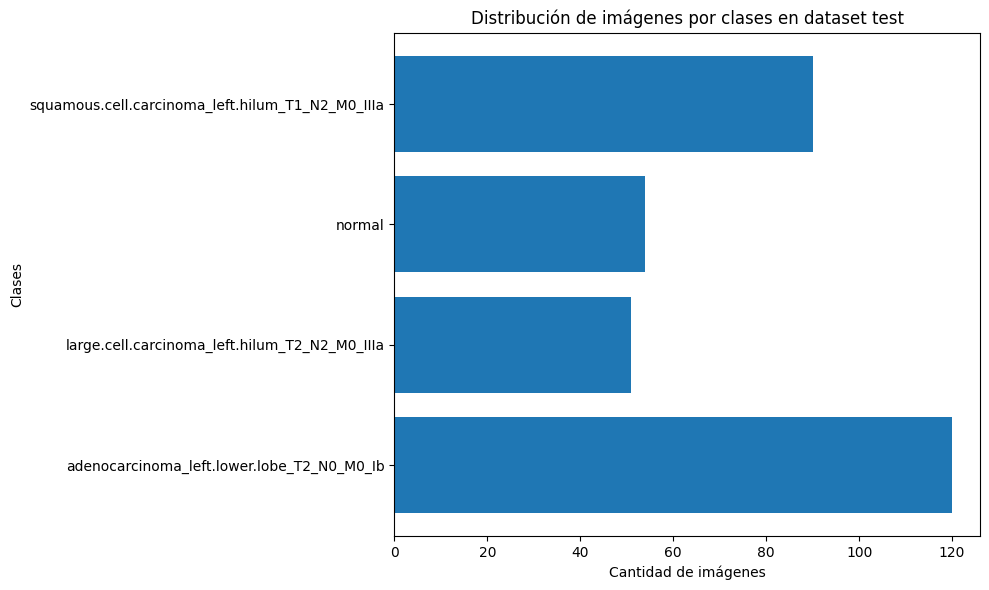

In [79]:
plot_image_class_distribution(dataset=test_data, datasetName="test")

El dataset de `validation` tiene la siguiente distribución de clases:

| Clase | Cantidad |
| --- | --- |
| `adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib` | $23$ |
| `large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa` | $21$ |
| `normal` | $13$ |
| `squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa` | $15$ |

Es decir, este dataset está ligeramente desbalanceado.

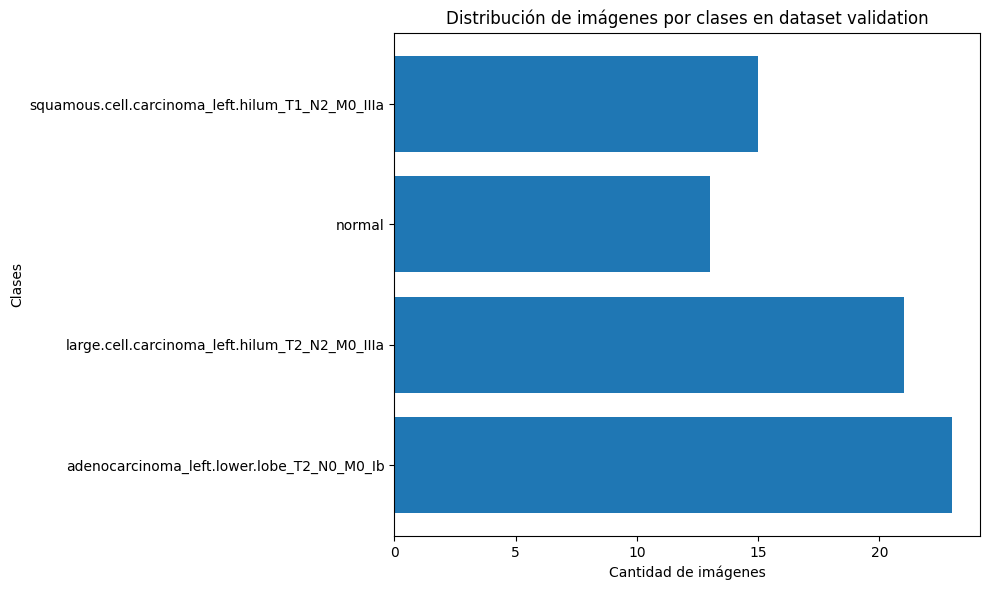

In [82]:
plot_image_class_distribution(dataset=validation_data, datasetName="validation")